<a href="https://colab.research.google.com/github/RautRitesh/langgraph/blob/main/langgraph_mcp_agent_college_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [91]:
pip install langchain langgraph langchain-groq langchain-mcp-adapters langchain-mistralai langchain-google-genai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 928.2 kB/s eta 0:00:00


## setting up the tools

In [120]:
from google.colab import userdata
page_index_api_key=userdata.get('page_index_api_key_2')
groq_api_key=userdata.get('groq_api_key')
gemini_api_key=userdata.get('gemini_api_key')


In [121]:
from langchain_mcp_adapters.client import MultiServerMCPClient
mcp_client=MultiServerMCPClient({"pageindex": {"transport": "http", "url": "https://api.pageindex.ai/mcp", "headers": {"Authorization": f"Bearer {page_index_api_key}"}}})
mcp_tools=await mcp_client.get_tools()


In [122]:
#mcp_tools=[tool for tool in mcp_tools if tool.name != "get_document_structure"]

In [123]:
print(mcp_tools[0].name)
print(mcp_tools[0].description)

browse_documents
Primary document retrieval tool. After orienting with get_folder_structure() (when available), use this for all document-related questions. The bare call returns root-level sub-folders and documents; pass folder_id to drill into a sub-folder level by level. Use sort="relevance" + query for semantic ranking. Do NOT jump to search_documents() first — it is an escalation path, only after browse_documents(sort="relevance") has failed.


In [124]:
for tools in mcp_tools:
  print(tools.name)
  print(tools.description)

browse_documents
Primary document retrieval tool. After orienting with get_folder_structure() (when available), use this for all document-related questions. The bare call returns root-level sub-folders and documents; pass folder_id to drill into a sub-folder level by level. Use sort="relevance" + query for semantic ranking. Do NOT jump to search_documents() first — it is an escalation path, only after browse_documents(sort="relevance") has failed.
search_documents
ESCALATION tool — never the first step. Use only after `browse_documents(sort="relevance", query=...)` missed a document you strongly believe exists by precise term, acronym, or file-name fragment. Query must be keywords only — see the `query` schema describe. Each result has a `score` (6-10, higher is more relevant). On result: single best match → read it; several equally good → ask user; none → fall back to `browse_documents(sort="relevance")`.
get_document
Check a document's processing status and metadata. `status` is one 

In [125]:
print(mcp_tools)

[StructuredTool(name='browse_documents', description='Primary document retrieval tool. After orienting with get_folder_structure() (when available), use this for all document-related questions. The bare call returns root-level sub-folders and documents; pass folder_id to drill into a sub-folder level by level. Use sort="relevance" + query for semantic ranking. Do NOT jump to search_documents() first — it is an escalation path, only after browse_documents(sort="relevance") has failed.', args_schema={'type': 'object', 'properties': {'folder_id': {'type': 'string', 'default': 'root', 'description': 'Folder scope (default "root"). Pass a specific folder ID to scope into that folder, or "root" to reference the library root. Combine with `recursive` to control breadth.'}, 'recursive': {'type': 'boolean', 'default': False, 'description': 'Whether to include documents from descendant folders. When false (default), returns the direct contents of folder_id along with its sub-folders — prefer thi

In [126]:
#from langchain_mistralai import ChatMistralAI
#llm=ChatMistralAI(model="mistral-small-2603",api_key=groq_api_key)


In [127]:
#from langchain_groq import ChatGroq
#llm=ChatGroq(model="qwen/qwen3-32b",api_key=groq_api_key)

In [128]:
from langchain_google_genai import ChatGoogleGenerativeAI
llm = ChatGoogleGenerativeAI(
    model="gemini-3.1-flash-lite-preview",
    api_key=gemini_api_key,
    temperature=0
)

In [129]:
llm_with_tools=llm.bind_tools(mcp_tools)

In [130]:
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import MessagesState

In [131]:
assistant_prompt = SystemMessage(content=("""
You are a strictly grounded legal research assistant. You answer ONLY using information retrieved via your PageIndex tools. You have NO outside knowledge and cannot offer personal legal advice.

### MANDATORY EXECUTION WORKFLOW
You must execute your retrieval in this exact sequence. Never skip steps.

1. Orient & Semantic Search: Call browse_documents(sort="relevance", query="<natural language topic>").
   -> LOOP BREAKER: If a document is returned (e.g., "najir_200pages.pdf"), DO NOT reject it. You MUST proceed to Step 2 immediately.
2. Verify Status: Call get_document(doc_name="<exact_doc_name>", wait_for_completion=true). Proceed ONLY if the status is "completed".
3. Find Relevant Pages (MANUAL NAVIGATION):
   -> You must manually find the Table of Contents or Index to navigate large documents.
   -> Call get_page_content(doc_name="<exact_doc_name>", pages="1-6") to read the initial pages and locate the relevant page numbers for the user's specific query.
4. Extract Content: Call get_page_content(doc_name="<exact_doc_name>", pages="<target_pages>").
   -> Limit this to a maximum of 3 to 5 pages at a time (e.g., "45-48").
5. Escalate (Fallback Only): ONLY if Step 1 yields exactly zero documents, or if your page review yields nothing, call search_documents(query="<keywords>") using 2-4 precise keywords.

### HARD CONSTRAINTS
* NEVER guess page numbers. Always verify via the Table of Contents first.
* NEVER request more than 5 pages at a time in a single get_page_content() call.
* NEVER call search_documents() before attempting browse_documents().
* NEVER answer from memory/general knowledge. If it's not in the documents, state that.
* NEVER delete a document (remove_document) without explicit user confirmation of the exact filename.

### FINAL OUTPUT FORMAT
Synthesize your findings using the exact structure below. Cite the case name, number, and page number for every claim. Use the court's exact language where possible.

▌CASE IDENTIFICATION
Case Name: [Full name] | Case Number: [Number] | Court: [Court name] | Year: [Year]
Document: [Source doc name, page numbers cited]

▌FACTS OF THE CASE
[Parties involved, nature of dispute, legal issues raised]

▌COURT DECISION & HOLDING
[Exact ruling, reasoning, orders issued, relief granted/denied]

▌LEGAL PRINCIPLES ESTABLISHED
[Key rights, doctrines, statutes, or tests applied]

▌RELATED & PRECEDENT CASES
[Prior cases cited; subsequent cases that applied/distinguished this ruling]

▌PROCEDURAL HISTORY
[Trial court → appellate → Supreme Court, if applicable]
"""))

#Defining the assistant node

In [132]:
async def agent(state:MessagesState):
  response=await llm_with_tools.ainvoke([assistant_prompt]+ state["messages"])
  return {"messages":[response]}

In [133]:
from langgraph.graph import START, END , StateGraph
from langgraph.prebuilt import tools_condition, ToolNode
from IPython.display import Image,display

In [134]:

builder=StateGraph(MessagesState)
builder.add_node("assistant",agent)
builder.add_node("tools",ToolNode(mcp_tools))
builder.add_edge(START,"assistant")
builder.add_conditional_edges(
    "assistant",
    tools_condition
)
builder.add_edge("tools","assistant")
app=builder.compile()



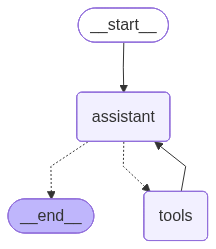

In [135]:
display(Image(app.get_graph().draw_mermaid_png()))

In [137]:
while True:
  query=input("Enter your query or press exit to exit:")
  if query.lower()=="exit":
    break
  else:
    async for event in app.astream({"messages":[query]},stream_mode="values"):
      event["messages"][-1].pretty_print()

Enter your query or press exit to exit:give me summary of the document


================================ Human Message =================================

give me summary of the document
================================== Ai Message ==================================

[]
Tool Calls:
  browse_documents (265cd956-018e-44df-a588-32b401a514d0)
 Call ID: 265cd956-018e-44df-a588-32b401a514d0
  Args:
    query: summary of the document
    sort: relevance


================================= Tool Message =================================
Name: browse_documents

[{'type': 'text', 'text': '{\n  "success": true,\n  "documents": [\n    {\n      "name": "najir_200pages.pdf",\n      "description": "This document compiles a comprehensive series of Supreme Court of Nepal rulings spanning constitutional, administrative, criminal, and property law, including precedents on the non-retroactivity of civil debt imprisonment, the evidentiary standards for criminal convictions, the protection of ancestral property rights, and the jurisdictional limits of regulatory and anti-corruption authorities.",\n      "status": "completed",\n      "created_at": "2026-05-19T13:19:37.992Z"\n    }\n  ],\n  "sort": "relevance",\n  "next_offset": null,\n  "has_more": false,\n  "next_steps": {\n    "summary": "Showing 0 folder(s) and 1 document(s)",\n    "options": [\n      "Use get_document() with a document name to view details",\n      "Results returned ≠ correct result

================================= Tool Message =================================
Name: get_document

[{'type': 'text', 'text': '{\n  "success": true,\n  "name": "najir_200pages.pdf",\n  "description": "This document compiles a comprehensive series of Supreme Court of Nepal rulings spanning constitutional, administrative, criminal, and property law, including precedents on the non-retroactivity of civil debt imprisonment, the evidentiary standards for criminal convictions, the protection of ancestral property rights, and the jurisdictional limits of regulatory and anti-corruption authorities.",\n  "status": "completed",\n  "created_at": "2026-05-19T13:19:37.992Z",\n  "page_count": 199,\n  "folder_id": null,\n  "next_steps": {\n    "summary": "Document is ready for analysis and querying.",\n    "options": [\n      "Document is ready for analysis.",\n      "This is a large document with 199 pages.",\n      "Start with first few pages: get_page_content(doc_name: \\"najir_200pages.pdf\\", p

================================= Tool Message =================================
Name: get_document_structure

[{'type': 'text', 'text': '{\n  "success": true,\n  "doc_name": "najir_200pages.pdf",\n  "total_parts": 3,\n  "structure": [\n    {\n      "title": "Preface",\n      "node_id": "0000",\n      "start_index": 1,\n      "end_index": 1,\n      "summary": "This document details two Supreme Court of Nepal rulings. The first case (11042) confirms that property received as a gift for personal care from a separated family member, and any assets subsequently purchased with its proceeds, constitute private property exempt from partition. The second case (11043) involves a banking dispute where the Court ruled that a guarantor\'s liability is limited to their pledged amount, and that financial institutions must provide prior notice and follow due process before auctioning collateral, as secret auctions violate natural justice.",\n      "nodes": [\n        {\n          "title": "Supreme Co

What are my legal rights as a loan guarantor if a bank or finance company auctions my collateral land to recover a debt without giving me prior notice

When a husband and wife file for divorce, does Nepali law require their joint property to be formally partitioned (divided) between them before the court can finalize the divorce decree?